# Homework for Lab 3.4

## 3.4.1 RNNs on the Daily Minimum Temperatures Dataset

#### Load dataset

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])


### Many-to-one

#### Dataset

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
  device = 'cuda'
  torch.cuda.manual_seed(42)
  torch.cuda.manual_seed_all(42)

print(f"Using device: {device}")

Using device: cuda


In [5]:
from sklearn.preprocessing import MinMaxScaler

y = df.Temp
y = y.to_numpy()

# Normalize
y = y.reshape(-1, 1)
scaler = MinMaxScaler()
y_normalized = scaler.fit_transform(y)

def create_many_to_one_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length] # many input steps
        y = data[i+seq_length] # one output step
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 25
X, y = create_many_to_one_sequences(y, SEQ_LENGTH)

# Train, val, test splits
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

##### Dataset and dataloader

In [6]:
from torch.utils.data import Dataset, DataLoader

class TempSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TempSeriesDataset(X_train, y_train)
val_dataset = TempSeriesDataset(X_val, y_val)
test_dataset = TempSeriesDataset(X_test, y_test)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
# Visualization

for i, (inputs, targets) in enumerate(train_loader):
    print("Inputs (one sample):", inputs[0])
    print("Inputs shape:", inputs.shape)
    print("Targets:", targets)
    print("Targets shape:", targets.shape)
    break

Inputs (one sample): tensor([[20.1000],
        [19.9000],
        [22.0000],
        [20.5000],
        [22.1000],
        [20.6000],
        [15.0000],
        [20.6000],
        [21.5000],
        [16.2000],
        [14.1000],
        [14.5000],
        [21.1000],
        [15.9000],
        [15.2000],
        [13.1000],
        [13.2000],
        [12.5000],
        [15.2000],
        [17.6000],
        [15.5000],
        [16.7000],
        [16.3000],
        [15.1000],
        [12.7000]])
Inputs shape: torch.Size([32, 25, 1])
Targets: tensor([[10.0000],
        [ 9.4000],
        [ 9.7000],
        [ 9.9000],
        [12.5000],
        [ 7.2000],
        [14.4000],
        [11.5000],
        [ 9.9000],
        [22.0000],
        [12.0000],
        [ 9.6000],
        [16.6000],
        [12.2000],
        [12.6000],
        [ 4.6000],
        [13.3000],
        [10.1000],
        [14.9000],
        [ 6.8000],
        [ 4.9000],
        [ 9.0000],
        [10.3000],
        [ 7.5000],


##### Visualization

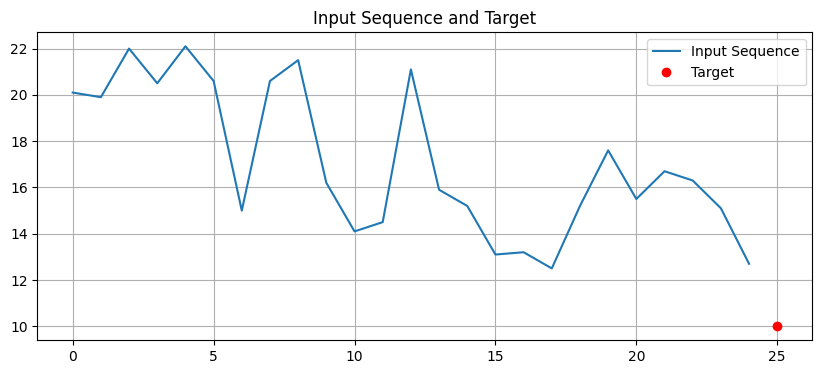

In [8]:
def plot_sequence(input, target, prediction=None):
    plt.figure(figsize=(10, 4))
    plt.plot(input, label='Input Sequence')
    plt.plot(np.arange(SEQ_LENGTH, SEQ_LENGTH + 1), target, 'ro', label='Target')
    if prediction is not None:
        plt.plot(np.arange(SEQ_LENGTH, SEQ_LENGTH + 1), prediction, 'gs', label='Prediction')
        plt.title('Input Sequence, Target, and Prediction')
    else:
        plt.title('Input Sequence and Target')

    plt.legend()
    plt.grid(True)
    plt.show()

sample_idx = 0

plot_sequence(inputs[0], targets[0])

#### Model

In [9]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # the rnn returns output and hidden state
        out, _ = self.rnn(x) # out.shape = ( batch, time step, hidden dim )
        # we only need the last time step as output
        out = self.fc(out[:, -1, :])
        return out
    
many2one_model = RNNModel()
many2one_model = many2one_model.to('cpu')



#### Training

In [10]:
NUM_EPOCHS = 100

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(many2one_model.parameters(), lr=0.001)

model = many2one_model.to(device)
history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):

    model.train()
    train_loss = 0.0

    for batch_x, batch_y in train_loader:

        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        preds = model(batch_x)
        loss = loss_function(preds, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:

            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            preds = model(batch_x)
            loss = loss_function(preds, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    history['val_loss'].append(val_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 10/100, Train Loss: 7.2698, Val Loss: 6.3469
Epoch 20/100, Train Loss: 6.3265, Val Loss: 5.1206
Epoch 30/100, Train Loss: 6.0516, Val Loss: 4.8796
Epoch 40/100, Train Loss: 5.9587, Val Loss: 4.5837
Epoch 50/100, Train Loss: 5.9627, Val Loss: 4.5383
Epoch 60/100, Train Loss: 5.8997, Val Loss: 4.5064
Epoch 70/100, Train Loss: 5.8936, Val Loss: 4.5049
Epoch 80/100, Train Loss: 5.8777, Val Loss: 4.5417
Epoch 90/100, Train Loss: 5.8906, Val Loss: 4.6034
Epoch 100/100, Train Loss: 5.8115, Val Loss: 4.4749


training time: 1m8.5s

##### Training and validation loss plot

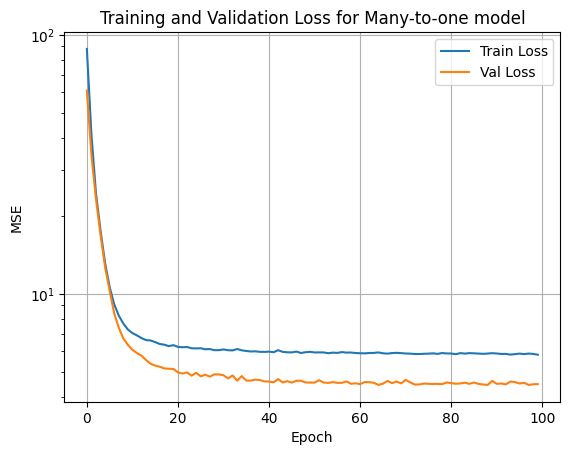

In [11]:
plt.figure()
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss for Many-to-one model')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

##### Evalutation of Many-to-one

In [12]:
model.eval()
test_loss = 0.0
inputs = []
predictions = []
actuals = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        preds = model(batch_x)
        loss = loss_function(preds, batch_y)
        test_loss += loss.item()
        inputs.append(batch_x.cpu().numpy())
        predictions.append(preds.cpu().numpy())
        actuals.append(batch_y.cpu().numpy())

test_loss /= len(test_loader)
print(f"Test MSE: {test_loss:.4f}")

# Concatenate inputs, predictions and actuals
inputs = np.concatenate(inputs)
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

Test MSE: 4.8282


**Many-to-One** Test MSE: 4.8282

##### Comparaison of prediction Vs actual on the whole test set 

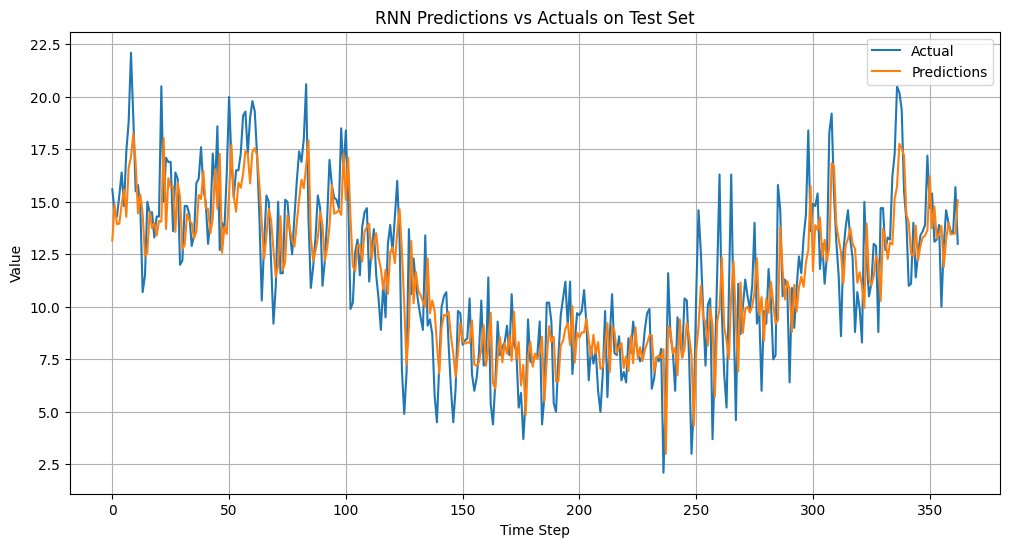

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(actuals, label='Actual')
plt.plot(predictions, label='Predictions')
plt.title('RNN Predictions vs Actuals on Test Set')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Many-to-Many


#### Dataset and DataLoaders

In [14]:
def create_many_to_many_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length] # many input steps
        # target is the same sequence shifted by one
        y = data[i+1:i+seq_length+1] # many output step
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 25
X, y = create_many_to_one_sequences(y, SEQ_LENGTH)

# Create the shifted sequences
X_m2m, y_m2m = create_many_to_many_sequences(y, SEQ_LENGTH)

# Split the data into train, val, test
train_size_m2m = int(len(X_m2m) * 0.8)
val_size_m2m = int(len(X_m2m) * 0.1)

X_train_m2m, y_train_m2m = X_m2m[:train_size_m2m], y_m2m[:train_size_m2m]
X_val_m2m, y_val_m2m = X_m2m[train_size_m2m:train_size_m2m+val_size_m2m], y_m2m[train_size_m2m:train_size_m2m+val_size_m2m]
X_test_m2m, y_test_m2m = X_m2m[train_size_m2m+val_size_m2m:], y_m2m[train_size_m2m+val_size_m2m:]

train_loader_m2m = DataLoader(TempSeriesDataset(X_train_m2m, y_train_m2m), batch_size=32, shuffle=True)
val_loader_m2m = DataLoader(TempSeriesDataset(X_val_m2m, y_val_m2m), batch_size=32, shuffle=False)
test_loader_m2m = DataLoader(TempSeriesDataset(X_test_m2m, y_test_m2m), batch_size=32, shuffle=False)

#### Training

We want to set the target datas and sequence length: here a many-to-many RNN.

In [15]:
# Visualization

for i, (inputs, targets) in enumerate(train_loader_m2m):
    print("Inputs (one sample):", inputs[0])
    print("Inputs shape:", inputs.shape)
    print("Targets:", targets)
    print("Targets shape:", targets.shape)
    break

Inputs (one sample): tensor([[15.8000],
        [13.6000],
        [11.9000],
        [ 9.9000],
        [12.6000],
        [17.8000],
        [15.0000],
        [13.6000],
        [13.4000],
        [10.5000],
        [14.2000],
        [11.5000],
        [13.0000],
        [15.0000],
        [14.7000],
        [12.6000],
        [12.5000],
        [13.5000],
        [14.8000],
        [17.2000],
        [ 9.7000],
        [12.1000],
        [12.8000],
        [11.2000],
        [16.4000]])
Inputs shape: torch.Size([32, 25, 1])
Targets: tensor([[[13.6000],
         [11.9000],
         [ 9.9000],
         [12.6000],
         [17.8000],
         [15.0000],
         [13.6000],
         [13.4000],
         [10.5000],
         [14.2000],
         [11.5000],
         [13.0000],
         [15.0000],
         [14.7000],
         [12.6000],
         [12.5000],
         [13.5000],
         [14.8000],
         [17.2000],
         [ 9.7000],
         [12.1000],
         [12.8000],
         [11.200

In [16]:
class RNNManyToMany(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNManyToMany, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out shape: (batch, seq_len, hidden_size)
        out, _ = self.rnn(x)
        # This time, apply the linear layer to **all** time steps
        out = self.fc(out)
        return out

model_m2m = RNNManyToMany()
model_m2m.to('cpu')

sample_idx = 0
sample_x = inputs[sample_idx]
sample_y = targets[sample_idx]

with torch.no_grad():
    example_prediction = model_m2m(sample_x.unsqueeze(0))

##### Visualization

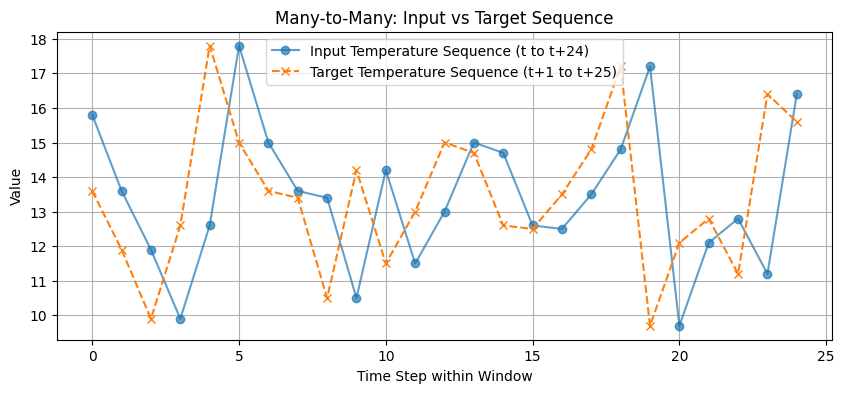

In [17]:
sample_idx = 0
sample_x = inputs[sample_idx]
sample_y = targets[sample_idx]

plt.figure(figsize=(10, 4))
plt.plot(sample_x, label='Input Temperature Sequence (t to t+24)', marker='o', alpha=0.7)
plt.plot(sample_y, label='Target Temperature Sequence (t+1 to t+25)', marker='x', linestyle='--')
plt.title('Many-to-Many: Input vs Target Sequence')
plt.xlabel('Time Step within Window')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

#### Model

In [18]:
class RNNManyToMany(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNManyToMany, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out shape: (batch, seq_len, hidden_size)
        out, _ = self.rnn(x)
        # This time, apply the linear layer to **all** time steps
        out = self.fc(out)
        return out
    
model_m2m = RNNManyToMany()
model_m2m.to('cpu')

RNNManyToMany(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

##### Visualization

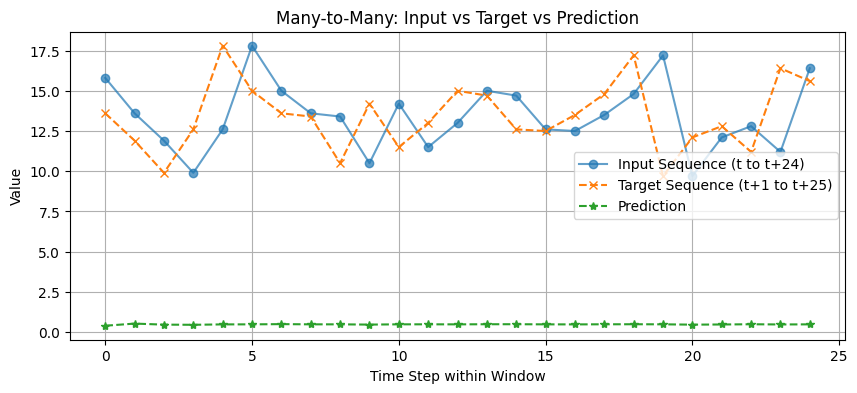

In [19]:
sample_x = inputs[sample_idx]
sample_y = targets[sample_idx]

with torch.no_grad():
    example_prediction = model_m2m(sample_x.unsqueeze(0))

plt.figure(figsize=(10, 4))
plt.plot(sample_x, label='Input Sequence (t to t+24)', marker='o', alpha=0.7)
plt.plot(sample_y, label='Target Sequence (t+1 to t+25)', marker='x', linestyle='--')
plt.plot(example_prediction.squeeze().numpy(), label='Prediction', marker='*', linestyle='--')
plt.title('Many-to-Many: Input vs Target vs Prediction')
plt.xlabel('Time Step within Window')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

#### Training

In [20]:
# Training Loop
m2m_model = RNNManyToMany().to(device)
optimizer_m2m = torch.optim.Adam(m2m_model.parameters(), lr=0.001)
criterion_m2m = nn.MSELoss()

m2m_history = {'loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    m2m_model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader_m2m:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        preds = m2m_model(batch_x)
        loss = criterion_m2m(preds, batch_y)

        optimizer_m2m.zero_grad()
        loss.backward()
        optimizer_m2m.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_m2m)
    m2m_history['loss'].append(avg_loss)

    # Validation
    m2m_model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader_m2m:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = m2m_model(batch_x)
            val_loss = criterion_m2m(preds, batch_y)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader_m2m)
    m2m_history['val_loss'].append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 10/100, Loss: 7.5855, Val Loss: 7.2192
Epoch 20/100, Loss: 6.2518, Val Loss: 5.2581
Epoch 30/100, Loss: 6.0444, Val Loss: 4.9427
Epoch 40/100, Loss: 5.9738, Val Loss: 4.7372
Epoch 50/100, Loss: 5.9009, Val Loss: 4.6671
Epoch 60/100, Loss: 5.8819, Val Loss: 4.6117
Epoch 70/100, Loss: 5.8558, Val Loss: 4.5942
Epoch 80/100, Loss: 5.8016, Val Loss: 4.6304
Epoch 90/100, Loss: 5.7610, Val Loss: 4.6123
Epoch 100/100, Loss: 5.6944, Val Loss: 4.6497


training time: 49.7s

##### Visualization

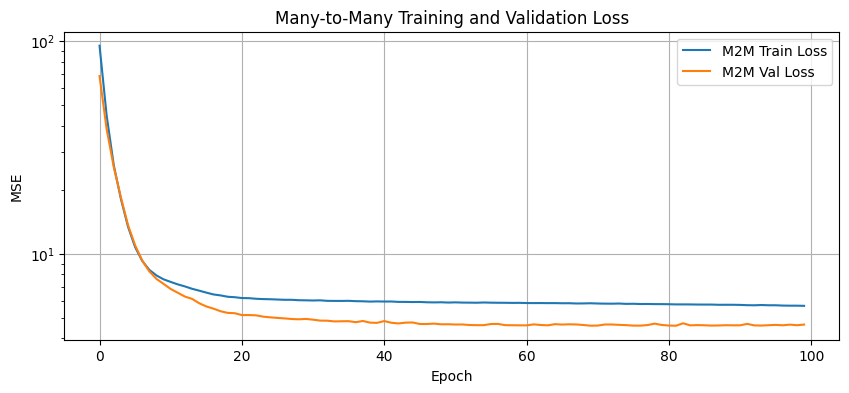

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(m2m_history['loss'], label='M2M Train Loss')
plt.plot(m2m_history['val_loss'], label='M2M Val Loss')
plt.title('Many-to-Many Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

#### Evalutation of Many-to-Many Model 

In [22]:
m2m_model.eval()
test_loss = 0.0

with torch.no_grad():
    for sample_x, sample_y in test_loader_m2m:

        sample_x = sample_x.to(device)
        sample_y = sample_y.to(device)

        preds = m2m_model(sample_x)

        loss = loss_function(preds, sample_y)

        test_loss += loss.item()
    
    sample_x, sample_y = next(iter(test_loader_m2m))
    sample_x = sample_x[0:1].to(device)
    prediction = m2m_model(sample_x).cpu().numpy().squeeze()
    actual = sample_y[0].cpu().numpy().squeeze()

test_loss /= len(test_loader_m2m)

print(f"Test MSE: {test_loss:.4f}")


Test MSE: 5.1892


**Many-to-Many** Test MSE: 5.1131

##### Comparaison of prediction Vs actual on the whole test set 

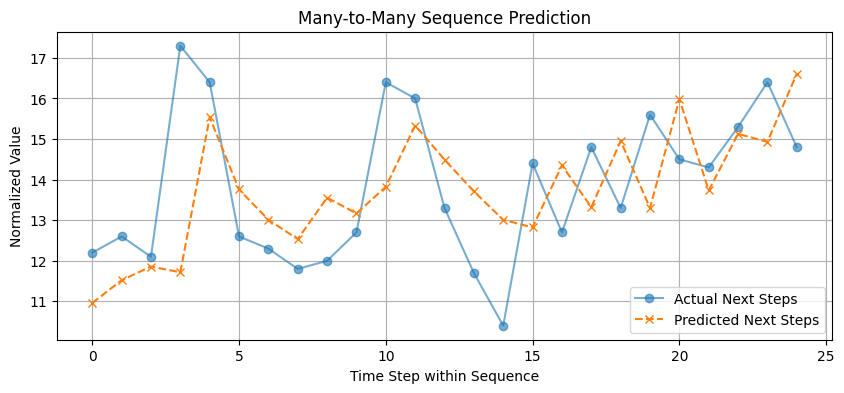

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(actual, label='Actual Next Steps', marker='o', alpha=0.6)
plt.plot(prediction, label='Predicted Next Steps', linestyle='--', marker='x')
plt.title('Many-to-Many Sequence Prediction')
plt.xlabel('Time Step within Sequence')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True)
plt.show()

## 3.4.2 Row-by-Row RNN for MNIST

#### Dataset and data loader

We load the MNIST dataset : 

In [ ]:
from torch.utils.data import Dataset
import torch
from torchvision.datasets import MNIST
from torchvision import transforms, datasets
from torch.utils.data import random_split, DataLoader
from torch.utils.data import TensorDataset
from torchvision.transforms import v2



# transform image data to tensor + normalize

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

mnist_train = MNIST(root='data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='data', train=False, download=True, transform=transform)
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000,10000]) # obtain train set and validation set

batch_size = 512

# converts a dataset (subset or actual dataset) to a TensorDataset with transformations applied
def split_to_tensor_dataset(dataset):

    if isinstance(dataset, torch.utils.data.Subset):
        data = dataset.dataset.data[dataset.indices]
        labels = dataset.dataset.targets[dataset.indices]
    elif isinstance(dataset, torch.utils.data.Dataset):
        data = dataset.data
        labels = dataset.targets
    

    # apply pre-transform
    transformed_data = []
    for img in data:
        transformed_img = transform(img)
        transformed_data.append(transformed_img)
    
    # recreate tensor
    data = torch.stack(transformed_data).to(device)
    labels = labels.to(device) 
    
    return TensorDataset(data, labels)

# Conversions

tdataset_train = split_to_tensor_dataset(mnist_train)
tdataset_valid = split_to_tensor_dataset(mnist_val)
tdataset_test = split_to_tensor_dataset(mnist_test)

# DataLoaders (pin_memory=False car déjà sur GPU)
train_loader = DataLoader(tdataset_train, batch_size=512, shuffle=True)
val_loader   = DataLoader(tdataset_valid, batch_size=512)
test_loader  = DataLoader(tdataset_test,  batch_size=512)



#### Model

In [25]:
# Visualization

for i, (inputs, targets) in enumerate(tdataset_train):
    print("Inputs (one sample):", inputs[0])
    print("Inputs shape:", inputs.shape)
    print("Targets:", targets)
    print("Targets shape:", targets.shape)
    break


Inputs (one sample): tensor([[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0

In [26]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        # the rnn returns output and hidden state
        out, _ = self.rnn(x) # out.shape = ( batch, time step, hidden dim )
        # we only need the last time step as output
        out = self.fc(out[:, -1, :])
        return out
    
m2o_model = RNNModel(input_size = 28, hidden_size = 8, num_layers = 2)

##### Model infos

In [28]:
!pip install torchinfo

In [30]:
from torchinfo import summary

print(summary(m2o_model, input_size=(batch_size, 28, 28)))

print('\n\nParameters:')
for name, param in m2o_model.named_parameters():
    print(f"Parameter {name}, shape {param.shape}, number of elements {param.numel()}")

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [512, 10]                 --
├─RNN: 1-1                               [512, 28, 8]              448
├─Linear: 1-2                            [512, 10]                 90
Total params: 538
Trainable params: 538
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 6.47
Input size (MB): 1.61
Forward/backward pass size (MB): 0.96
Params size (MB): 0.00
Estimated Total Size (MB): 2.57


Parameters:
Parameter rnn.weight_ih_l0, shape torch.Size([8, 28]), number of elements 224
Parameter rnn.weight_hh_l0, shape torch.Size([8, 8]), number of elements 64
Parameter rnn.bias_ih_l0, shape torch.Size([8]), number of elements 8
Parameter rnn.bias_hh_l0, shape torch.Size([8]), number of elements 8
Parameter rnn.weight_ih_l1, shape torch.Size([8, 8]), number of elements 64
Parameter rnn.weight_hh_l1, shape torch.Size([8, 8]), number of elements 64
Parameter rnn.bias_ih_l1, shape tor

#### Training

In [31]:
NUM_EPOCHS = 30

# classification problem -> cross entropy
loss_module = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m2o_model.parameters(), lr=0.001)

model = m2o_model.to(device)
history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):

    model.train()
    train_loss = 0.0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.squeeze(1) # (batch, 1, 28, 28) to (batch, 28, 28)

        preds = model(batch_x)
        loss = loss_module(preds, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:

            batch_x = batch_x.squeeze(1) # (batch, 1, 28, 28) to (batch, 28, 28)

            preds = model(batch_x)
            loss = loss_module(preds, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    history['val_loss'].append(val_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 10/30, Train Loss: 1.2792, Val Loss: 1.2761
Epoch 20/30, Train Loss: 1.0360, Val Loss: 1.0508
Epoch 30/30, Train Loss: 0.8778, Val Loss: 0.8898


training time: 43.3s

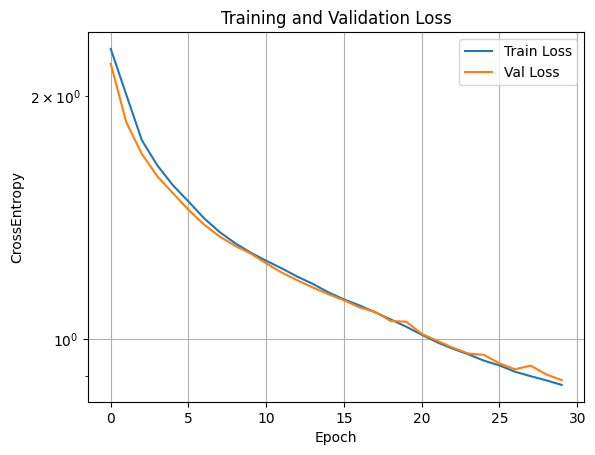

In [32]:
plt.figure()
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

#### Evaluation

In [33]:
model.eval()
test_loss = 0.0
correct = 0
total = 0
inputs = []
predictions = []
actuals = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.squeeze(1)
        preds = model(batch_x)
        loss = loss_module(preds, batch_y)
        test_loss += loss.item()

        predicted = preds.argmax(dim=1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

        inputs.append(batch_x.cpu().numpy())
        predictions.append(preds.cpu().numpy())
        actuals.append(batch_y.cpu().numpy())

test_loss /= len(test_loader)
accuracy = 100 * correct / total
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

# Concatenate inputs, predictions and actuals
inputs = np.concatenate(inputs)
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

Test Loss: 0.8844
Test Accuracy: 70.06%


Test Loss: 0.8844
Test Accuracy: 70.06%

Example:

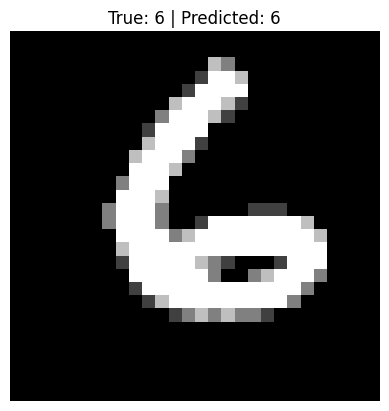

In [36]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(inputs)-1)
image = inputs[idx]

# real output
true_label = actuals[idx]

# predicted output
pred_label = np.argmax(predictions[idx])

plt.imshow(image, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {pred_label}")
plt.axis('off')
plt.show()